# Distribution of shrunken logFC per context, filtered genes only

One histogram per context over the **real** matrices, restricted to the genes that
survive the affected-gene filter. Subsample rows are excluded by default, so each
value is one perturbation's full-data estimate for one gene in one context.

The filter is read from a saved gene list rather than recomputed, so these histograms
describe exactly the genes the model is fitted on.

In [8]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

from extract import paths
from extract.data import apply_gene_list, load_gene_list
from extract.de import load_matrices

GENE_LIST = paths.root() / "gene_lists" / "affected_N100_thr0.1.tsv"
VARIANT = "main"        # "main" = full-data rows only; None = all 11 per perturbation
CONTEXTS = None         # None = every context with a built matrix
CLIP = 4.0              # histogram x-range, +/- this; tails reported separately
BINS = 120

In [2]:
GENE_LIST

PosixPath('/large_storage/ctc/beraslan/ModuleFinder/gene_lists/affected_N100_thr0.1.tsv')

In [3]:
genes_keep = load_gene_list(GENE_LIST)
X, meta = load_matrices(paths.matrices(), contexts=CONTEXTS, variant=VARIANT)
values, genes = apply_gene_list(X, genes_keep)
del X

contexts = meta["context"].to_numpy()
print(f"{values.shape[0]:,} rows x {values.shape[1]:,} genes")
print(f"contexts: {sorted(set(contexts))}")

  AR-A014418: 2,060 rows
  AZD4573: 2,039 rows
  Bisindolylmaleimide-I: 2,049 rows
  CHIR-98014: 2,026 rows
  DG-172: 2,079 rows
  DMSO_round2: 2,014 rows
  DMSO_round2_batch2: 2,016 rows
  Stattic: 2,067 rows
16,350 rows x 7,141 genes
contexts: ['AR-A014418', 'AZD4573', 'Bisindolylmaleimide-I', 'CHIR-98014', 'DG-172', 'DMSO_round2', 'DMSO_round2_batch2', 'Stattic']


In [4]:
contexts

array(['AR-A014418', 'AR-A014418', 'AR-A014418', ..., 'Stattic',
       'Stattic', 'Stattic'], shape=(16350,), dtype=object)

## Per-context histograms

Log-scaled counts: the distribution is dominated by values `ashr` shrank to near zero,
so on a linear count axis nothing else is visible.

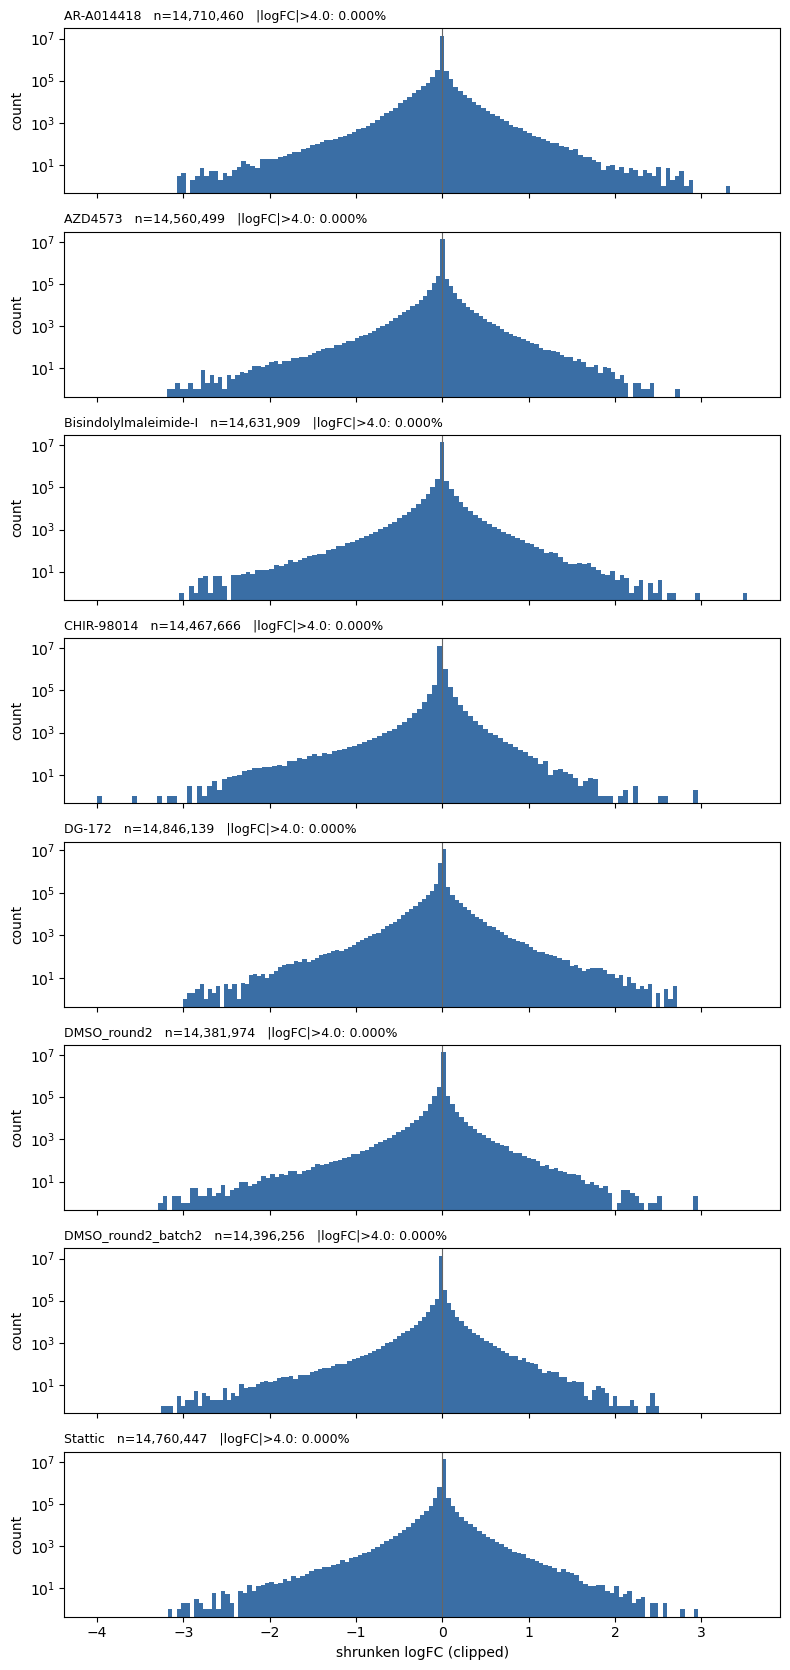

In [9]:
names = sorted(set(contexts))
fig, axes = plt.subplots(len(names), 1, figsize=(8, 2.1 * len(names)), sharex=True)
axes = np.atleast_1d(axes)

for ax, name in zip(axes, names):
    v = values[contexts == name].ravel()
    ax.hist(np.clip(v, -CLIP, CLIP), bins=BINS, color="#3A6EA5")
    ax.set_yscale("log")
    ax.set_ylabel("count")
    ax.axvline(0, color="0.4", lw=0.8)
    frac_out = float(np.mean(np.abs(v) > CLIP))
    ax.set_title(f"{name}   n={v.size:,}   |logFC|>{CLIP}: {frac_out:.3%}",
                 fontsize=9, loc="left")

axes[-1].set_xlabel("shrunken logFC (clipped)")
fig.tight_layout()

## Summary per context

`frac_near_zero` is the share `ashr` shrank below the filter threshold; it is the
quantity that makes the histograms look alike even when the contexts differ.

In [ ]:
rows = []
for name in names:
    v = values[contexts == name].ravel()
    a = np.abs(v)
    rows.append({
        "context": name,
        "n_rows": int((contexts == name).sum()),
        "sd": v.std(),
        "mean": v.mean(),
        "q01": np.quantile(v, 0.01),
        "q99": np.quantile(v, 0.99),
        "min": v.min(),
        "max": v.max(),
        "frac_near_zero": float(np.mean(a < 0.1)),
        "frac_gt_0.5": float(np.mean(a > 0.5)),
        "skew": float(((v - v.mean()) ** 3).mean() / v.std() ** 3),
    })

summary = pd.DataFrame(rows).set_index("context")
summary.round(4)

## Are the contexts on the same scale?

If shrinkage retained different amounts per context, the model sees rows whose
magnitudes are not comparable across contexts, and a factor could load on a context
rather than on biology. Overlaid densities of the non-negligible values make that
visible.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
grid = np.linspace(-CLIP, CLIP, 400)

for name in names:
    v = values[contexts == name].ravel()
    v = v[np.abs(v) > 0.1]                    # drop the shrunk-to-zero mass
    counts, edges = np.histogram(v, bins=grid, density=True)
    ax.plot(edges[:-1], counts, lw=1.2, label=f"{name} (n={v.size:,})")

ax.set_yscale("log")
ax.set_xlabel("shrunken logFC, |logFC| > 0.1 only")
ax.set_ylabel("density")
ax.legend(fontsize=7)
ax.set_title("non-negligible values, by context", fontsize=10, loc="left")
fig.tight_layout()